# BIS through navi's client

`BisClient` is navi's wrapper around the Bank for International Settlements SDMX
service — the same code the MCP server runs, one layer down. This notebook walks the
same arc as `walkthrough.ipynb` (discovery → structure → key → data → plot) but talks
to `stats.bis.org` directly, so **the MCP server does not need to be running**.

For every other source that trade is a running server for a configured API key. BIS
does not even ask for that: no key, no header, no registration, no quota to nurse. This
notebook runs with **no credentials at all** — a network connection is the whole
prerequisite.

BIS is also the source where discovery is unavoidable. A series here has no id, it has
*coordinates*: a key is the dataflow's dimension values joined by dots in a fixed order,
and only the data structure says what that order is and which codes each position
accepts. So `get_dataflows` → `get_datastructure` → build a key → `get_data` is not a
scenic route. It is the only way to reach a request that returns anything.

In [1]:
%reload_ext autoreload
%autoreload 2

import sys
sys.path.append('../')

from matplotlib import pyplot
sys.path.append("../../")   # repo root, for `clients`
from lib import config
from clients import BisClient
from utils import (
    show_client_dataflows,
    dsd_id_for_dataflow,
    show_client_datastructure,
    find_client_codes,
    show_client_series,
    client_unit_label,
    plot_client_series,
    first_csv_row,
)

pyplot.style.use(config.glyfish_style)

## 1. Discovery

Three methods, and they line up one-to-one with the three questions BIS makes you answer
in order: which dataset (`get_dataflows`), how a key in that dataset is shaped
(`get_datastructure`), and only then the numbers (`get_data`).

`BisClient()` takes no arguments because there is nothing to authenticate — only a base
url, which defaults to `https://stats.bis.org/api/v1` and is overridable with
`BIS_BASE_URL`. It owns an `httpx.AsyncClient`, so it is opened once here and closed at
the end of section 2.

In [2]:
client = BisClient()
print("base url:", client.base_url)
print()

flows = await client.get_dataflows()
show_client_dataflows(flows)

base url: https://stats.bis.org/api/v1

BIS_REL_CAL            BIS_RELEASE_CALENDAR
WS_CBPOL               Central bank policy rates
WS_CBS_PUB             Consolidated banking
WS_CBTA                Central bank total assets
WS_CPMI_CASHLESS       CPMI cashless payments
WS_CPMI_CT1            CPMI comparative tables type 1
WS_CPMI_CT2            CPMI comparative tables type 2
WS_CPMI_DEVICES        CPMI payment devices
WS_CPMI_INSTITUT       CPMI institutions
WS_CPMI_MACRO          CPMI macro
WS_CPMI_PARTICIP       CPMI participants
WS_CPMI_SYSTEMS        CPMI systems
WS_CPP                 Commercial property prices
WS_CREDIT_GAP          Credit-to-GDP gaps
WS_DEBT_SEC2_PUB       International debt securities (BIS-compiled)
WS_DER_OTC_TOV         OTC derivatives turnover
WS_DPP                 Detailed residential property prices
WS_DSR                 Debt service ratios
WS_EER                 Effective exchange rates
WS_GLI                 Global liquidity indicators
WS_LBS_D_PUB  

Every entry carries a `structure` urn, and that urn is where a data-structure id has to
come from. It is *usually* the flow id with `WS_` swapped for `BIS_` (WS_TC →
BIS_TOTAL_CREDIT), which is exactly what makes guessing dangerous: WS_CBTA is served by
`CBTA`, WS_SPP by `BIS_SELECTED_PP`, and WS_CPP and WS_DPP share one structure,
`BIS_PROP_PRICES`. Structures are objects in their own right, not a naming convention
on flows.

In [3]:
dsd_id = dsd_id_for_dataflow(flows, "WS_CBPOL")

WS_CBPOL: Central bank policy rates
  structure: urn:sdmx:org.sdmx.infomodel.datastructure.DataStructure=BIS:BIS_CBPOL(1.0)
  dsd_id:    BIS_CBPOL


The structure answers both questions a key raises: the *order* of the dimensions, and
the codelist that decodes each position.

Here the client and the MCP tool part company. `get_datastructure` asks for
`references=children` and returns every codelist in full — `CL_BIS_UNIT` alone holds
more than a thousand codes, and this one DSD materializes over 1,400 across eight lists
— because the client's job is to hand back what BIS sent. The `bis_datastructure` tool
wraps that same model in a view that blanks `codes` and reports `code_count` instead
unless the caller passes `include_codes=true`. The suppression is a tool-layer decision
about an agent's context budget; the client does not make it, and in a notebook nothing
is paying for those codes.

In [4]:
dsd = await client.get_datastructure(dsd_id)
show_client_datastructure(dsd)

print("\ncodes materialized:", sum(len(cl.codes) for cl in dsd.codelists.values()))
print("CL_FREQ:", dsd.codelists["CL_FREQ"].codes)

BIS_CBPOL: BIS Central Bank Policy Rates
dimensions (key order): ['FREQ', 'REF_AREA']
  1. FREQ             -> CL_FREQ
  2. REF_AREA         -> CL_BIS_GL_REF_AREA
  CL_BIS_GL_REF_AREA     239 codes
  CL_BIS_UNIT            1096 codes
  CL_CONF_STATUS         5 codes
  CL_DECIMALS            17 codes
  CL_FREQ                8 codes
  CL_OBS_STATUS          16 codes
  CL_TIME_FORMAT         19 codes
  CL_UNIT_MULT           11 codes

codes materialized: 1411
CL_FREQ: {'A': 'Annual', 'B': 'Daily - business week (not supported)', 'D': 'Daily', 'E': 'Event (not supported)', 'H': 'Half-yearly', 'M': 'Monthly', 'Q': 'Quarterly', 'W': 'Weekly'}


Two dimensions here, in this order: `FREQ`, then `REF_AREA`. A key is therefore
`<frequency>.<area>`, and the two codelists below are where each half must come from. A
position may be left empty to wildcard it (`M.` — monthly, every area), take
alternatives with `+` (`M.US+GB`), and `"all"` stands in for the entire flow.

In [5]:
find_client_codes(dsd, "FREQ")

print()
find_client_codes(dsd, "REF_AREA", "United")

key = "M.US"   # monthly, United States

FREQ -> CL_FREQ (8 codes)
  A        Annual
  B        Daily - business week (not supported)
  D        Daily
  E        Event (not supported)
  H        Half-yearly
  M        Monthly
  Q        Quarterly
  W        Weekly

REF_AREA -> CL_BIS_GL_REF_AREA (239 codes, 3 matching 'United')
  AE       United Arab Emirates
  GB       United Kingdom
  US       United States


In [6]:
# The codelist is BIS-wide, not per flow: 239 reference areas exist across the whole
# service, but a flow publishes far fewer. A wildcarded key is the cheapest way to see
# which ones this dataflow actually carries.
published = await client.get_data("WS_CBPOL", "M.", start_period="2024-01")

print(published.series_count, "areas publish a monthly policy rate:")
print(", ".join(sorted(s.dimensions["REF_AREA"] for s in published.series)))

39 areas publish a monthly policy rate:
AR, AU, BR, CA, CH, CL, CN, CO, CZ, DK, GB, HK, HU, ID, IL, IN, IS, JP, KR, KW, MA, MK, MX, MY, NO, NZ, PE, PH, PL, RO, RS, RU, SA, SE, TH, TR, US, XM, ZA


## 2. Retrieving a series

`get_data` asks BIS for `format=csv` — which sidesteps SDMX-XML entirely — and gets back
one row per observation with the whole series description repeated on every row. Below
is that payload untouched, straight off `client._get`, the private method the public one
wraps. Reaching for a private method is the point of this notebook rather than a lapse
in it: it is the only place the raw shape and the typed one can be put side by side.

In [7]:
raw = await client._get("/data/WS_CBPOL/M.US/all", params={"format": "csv"})
lines = raw.text.splitlines()

print("content-type:", raw.headers["content-type"])
print("rows:        ", len(lines), f"(1 header + {len(lines) - 1} observations)")
print()
print("columns:")
print(lines[0])
print()
print("first data row:")
print(lines[1])

content-type: text/csv;charset=UTF-8
rows:         867 (1 header + 866 observations)

columns:
FREQ,REF_AREA,UNIT_MEASURE,UNIT_MULT,TIME_FORMAT,COMPILATION,DECIMALS,SOURCE_REF,SUPP_INFO_BREAKS,TITLE,TIME_PERIOD,OBS_VALUE,OBS_STATUS,OBS_CONF,OBS_PRE_BREAK

first data row:
M,US,368,0,,From 19 Dec 1985 onwards: mid-point of the Federal Reserve target rate; from 1 Jul 1954 to 18 Dec 1985: US Fed Funds effective rate.,4,US Federal Reserve System,, Central bank policy rates - United States - Monthly - End of period,1954-07,0.25,A,F,


Ten of those fifteen columns describe the series, not the observation, and they are
repeated on all 866 rows to carry one number each. The raw payload has no notion of a
series at all — the grouping is something the client computes.

`get_data` parses that text into a `BisDataResponse`, and what the model adds is:

* **series, grouped** — rows sharing a dimension set become one `BisSeries`, with the
  repeated columns hoisted into `dimensions` once and a dot-joined `key` derived from
  them. One CSV can hold many series: the wildcard call above turned 1,214 data rows
  into 39.
* **parsed values** — `OBS_VALUE` is text in the CSV; `BisObservation.value` is an
  `Optional[float]`, already converted, with blanks and non-numeric placeholders landing
  as `None` rather than as `""`.
* **cleaned attributes** — `TITLE` arrives with a leading space; the model strips it and
  lifts it, with `UNIT_MEASURE`, onto the series itself.
* **ordering** — observations are sorted by `time_period`, which the CSV does not
  promise.
* **a validated, frozen shape** — pydantic models, so a malformed payload fails here
  instead of as a `KeyError` three cells later.

What it does *not* add is the translation work the other sources need. FRED and BLS
models spend their aliases renaming camelCase fields and unwrapping an HTTP envelope;
the BIS models have neither to undo. `BisDataResponse` is `{flow, series}` and an
observation is `{time_period, value, status}`, in snake_case, alias-free. That is why
`mcp_server/responses/bis.py` is mostly pass-throughs, and why for BIS — alone among
these sources — what the client returns and what the MCP tool returns are very nearly
the same object.

In [8]:
data = await client.get_data("WS_CBPOL", key)

print(type(data).__name__, "->", data.series_count, "series")
print()
show_client_series(data, dsd)

policy_rate = data.series[0]

BisDataResponse -> 1 series

M.US.368  Central bank policy rates - United States - Monthly - End of period
  decoded:  FREQ=Monthly, REF_AREA=United States
  unit:     Per cent per year
  coverage: 1954-07 -> 2026-08 (866 observations)


In [9]:
row = first_csv_row(raw.text)
first = policy_rate.observations[0]

print("raw   TITLE:       ", repr(row["TITLE"]))
print("raw   TIME_PERIOD: ", repr(row["TIME_PERIOD"]))
print("raw   OBS_VALUE:   ", repr(row["OBS_VALUE"]), type(row["OBS_VALUE"]).__name__)
print()
print("model title:       ", repr(policy_rate.title))
print("model observation: ", first)
print("model value:       ", repr(first.value), type(first.value).__name__)
print("model key:         ", policy_rate.key, "(attribute columns ride along)")
print("model unit:        ", policy_rate.unit_measure,
      "->", client_unit_label(dsd, policy_rate))

await client.aclose()   # nothing below needs the network

raw   TITLE:        ' Central bank policy rates - United States - Monthly - End of period'
raw   TIME_PERIOD:  '1954-07'
raw   OBS_VALUE:    '0.25' str

model title:        'Central bank policy rates - United States - Monthly - End of period'
model observation:  time_period='1954-07' value=0.25 status='A'
model value:        0.25 float
model key:          M.US.368 (attribute columns ride along)
model unit:         368 -> Per cent per year


## 3. Plot

`M.US` is the US policy rate, monthly, end of period — one of the few series where seven
decades stay legible on a single axis: 22% at the Volcker peak in December 1980, 0.125%
from the end of 2008 through 2015 and again through the pandemic, and near 3.6% today.

`plot_client_series` builds its arrays from the typed observations, so there is no
string parsing left to do, and it reports anything it had to drop — a null value, a
non-finite one, an unparseable period — instead of quietly plotting fewer points than
the series holds. The y-axis label is decoded rather than printed: `UNIT_MEASURE` is the
code `368`, and `CL_BIS_UNIT` says that means "Per cent per year".

866 observations, 866 plotted, 0 dropped


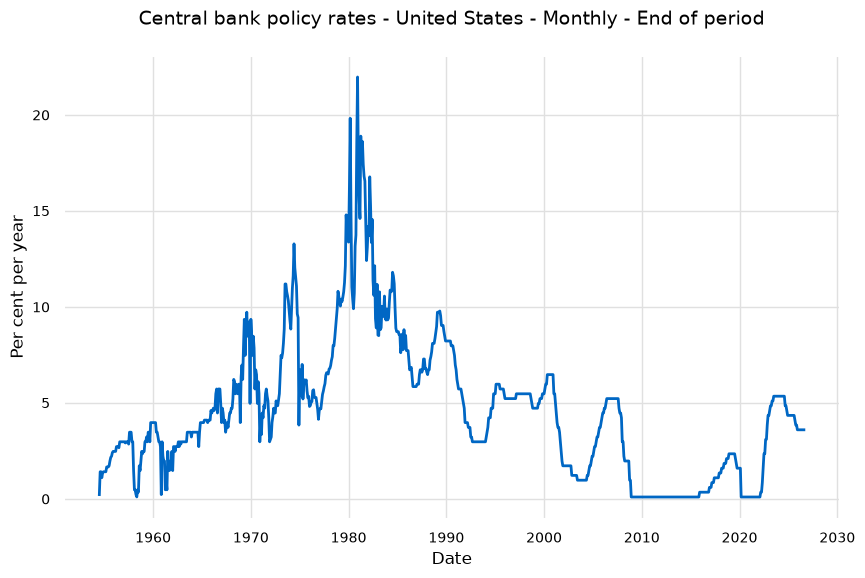

: 

In [ ]:
plot_client_series(policy_rate, dsd)